# Decision Tree

## Decision Tree Classifier

A Decision Tree classifier is a supervised learning algorithm that recursively splits the dataset 
based on feature values to create a tree-like structure for decision-making. Its interpretability 
makes it particularly suitable for medical applications, as clinicians can easily understand how 
predictions are derived from patient attributes

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

### Data Pre-processing for Decision Tree

Prior to training the Decision Tree model, the dataset was cleaned to remove physiologically invalid 
values. Features such as Glucose, Blood Pressure, and BMI contained zero values that represent 
missing or impossible medical measurements and were therefore excluded.

The Insulin attribute was removed due to a high proportion of missing values, which could introduce 
noise and bias into the model. Although Decision Trees are not sensitive to feature scaling, 
standardisation was applied for consistency across all machine learning models used in this study, 
enabling fair performance comparison.

## Dataset Loading

In [105]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/diabetes.csv")

# Preview dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#Clean_dataset

In [106]:
def clean_dataset(df):
    df = df.drop(columns=["Insulin"], errors="ignore")
    df = df[
        (df["Glucose"] > 0) &
        (df["BloodPressure"] > 0) &
        (df["BMI"] > 0)
    ]
    return df

#Standardize_features(X_train, X_test)

In [107]:
def standardize_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

## Train–Test Split

The dataset was split into training and testing subsets using a stratified train–test split to preserve the original class distribution. 
A fixed `random_state = 42` was used to ensure reproducibility of results across different runs.


In [132]:
def train_decision_tree(X_train, y_train, random_state=42):
    model = DecisionTreeClassifier(
        criterion="gini",
        random_state=random_state
    )
    model.fit(X_train, y_train)
    return model

In [133]:
def apply_smote(X_train, y_train, random_state=42):
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

In [134]:
def evaluate_model(y_true, y_pred, class_labels=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "roc_auc": roc_auc_score(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

    tn, fp, fn, tp = results["confusion_matrix"].ravel()
    results["specificity"] = tn / (tn + fp)
    results["sensitivity"] = tp / (tp + fn)

    if class_labels:
        results["classification_report"] = classification_report(
            y_true, y_pred, target_names=class_labels
        )

    return results

In [135]:
def display_results(results, model_name="Decision Tree", class_labels=None):
    print(f"\n{model_name.upper()} PERFORMANCE")
    print("=" * 70)

    if "classification_report" in results:
        print("\nClassification Report:")
        print(results["classification_report"])

    print(f"Accuracy             : {results['accuracy']:.6f}")
    print(f"Precision (weighted) : {results['precision_weighted']:.6f}")
    print(f"Recall (weighted)    : {results['recall_weighted']:.6f}")
    print(f"F1-score (weighted)  : {results['f1_weighted']:.6f}")
    print(f"ROC-AUC              : {results['roc_auc']:.6f}")
    print(f"Sensitivity          : {results['sensitivity']:.6f}")
    print(f"Specificity          : {results['specificity']:.6f}")

    if class_labels:
        print("\nConfusion Matrix:")
        print(pd.DataFrame(
            results["confusion_matrix"],
            index=class_labels,
            columns=class_labels
        ))

In [136]:
df = pd.read_csv("data/diabetes.csv")
df.head()
df = clean_dataset(df)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [137]:
X_train_scaled, X_test_scaled = standardize_features(X_train, X_test)

In [138]:
baseline_tree = train_decision_tree(X_train_scaled, y_train)

In [139]:
y_pred = baseline_tree.predict(X_test_scaled)


In [140]:
baseline_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    class_labels=["Non-Diabetic", "Diabetic"]
)

display_results(
    baseline_results,
    model_name="Decision Tree (Baseline)",
    class_labels=["Non-Diabetic", "Diabetic"]
)




DECISION TREE (BASELINE) PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.75      0.76        95
    Diabetic       0.54      0.56      0.55        50

    accuracy                           0.68       145
   macro avg       0.65      0.65      0.65       145
weighted avg       0.69      0.68      0.68       145

Accuracy             : 0.682759
Precision (weighted) : 0.685862
Recall (weighted)    : 0.682759
F1-score (weighted)  : 0.684181
ROC-AUC              : 0.653684
Sensitivity          : 0.560000
Specificity          : 0.747368

Confusion Matrix:
              Non-Diabetic  Diabetic
Non-Diabetic            71        24
Diabetic                22        28


In [141]:
X_train_smote, y_train_smote = apply_smote(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Outcome
0    380
1    199
Name: count, dtype: int64

After SMOTE:
Outcome
0    380
1    380
Name: count, dtype: int64


In [142]:
smote_tree= train_decision_tree(X_train_smote, y_train_smote)

In [143]:
y_pred_smote = smote_tree.predict(X_test_scaled)

In [144]:
smote_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_smote,
    class_labels=["Non-Diabetic", "Diabetic"]
)

display_results(
    smote_results,
    model_name="Decision Tree + SMOTE",
    class_labels=["Non-Diabetic", "Diabetic"]
)



DECISION TREE + SMOTE PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.73      0.75        95
    Diabetic       0.54      0.60      0.57        50

    accuracy                           0.68       145
   macro avg       0.66      0.66      0.66       145
weighted avg       0.69      0.68      0.69       145

Accuracy             : 0.682759
Precision (weighted) : 0.692672
Recall (weighted)    : 0.682759
F1-score (weighted)  : 0.686565
ROC-AUC              : 0.663158
Sensitivity          : 0.600000
Specificity          : 0.726316

Confusion Matrix:
              Non-Diabetic  Diabetic
Non-Diabetic            69        26
Diabetic                20        30


In [145]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [146]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_dt.fit(X_train_scaled, y_train)

tuned_tree = grid_dt.best_estimator_

print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [147]:
y_pred_tuned = tuned_tree.predict(X_test_scaled)

In [148]:
tuned_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_tuned,
    class_labels=["Non-Diabetic", "Diabetic"]
)

display_results(
    tuned_results,
    model_name="Decision Tree (Tuned)",
    class_labels=["Non-Diabetic", "Diabetic"]
)


DECISION TREE (TUNED) PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.78      0.77        95
    Diabetic       0.55      0.52      0.54        50

    accuracy                           0.69       145
   macro avg       0.65      0.65      0.65       145
weighted avg       0.69      0.69      0.69       145

Accuracy             : 0.689655
Precision (weighted) : 0.685478
Recall (weighted)    : 0.689655
F1-score (weighted)  : 0.687268
ROC-AUC              : 0.649474
Sensitivity          : 0.520000
Specificity          : 0.778947

Confusion Matrix:
              Non-Diabetic  Diabetic
Non-Diabetic            74        21
Diabetic                24        26


In [149]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


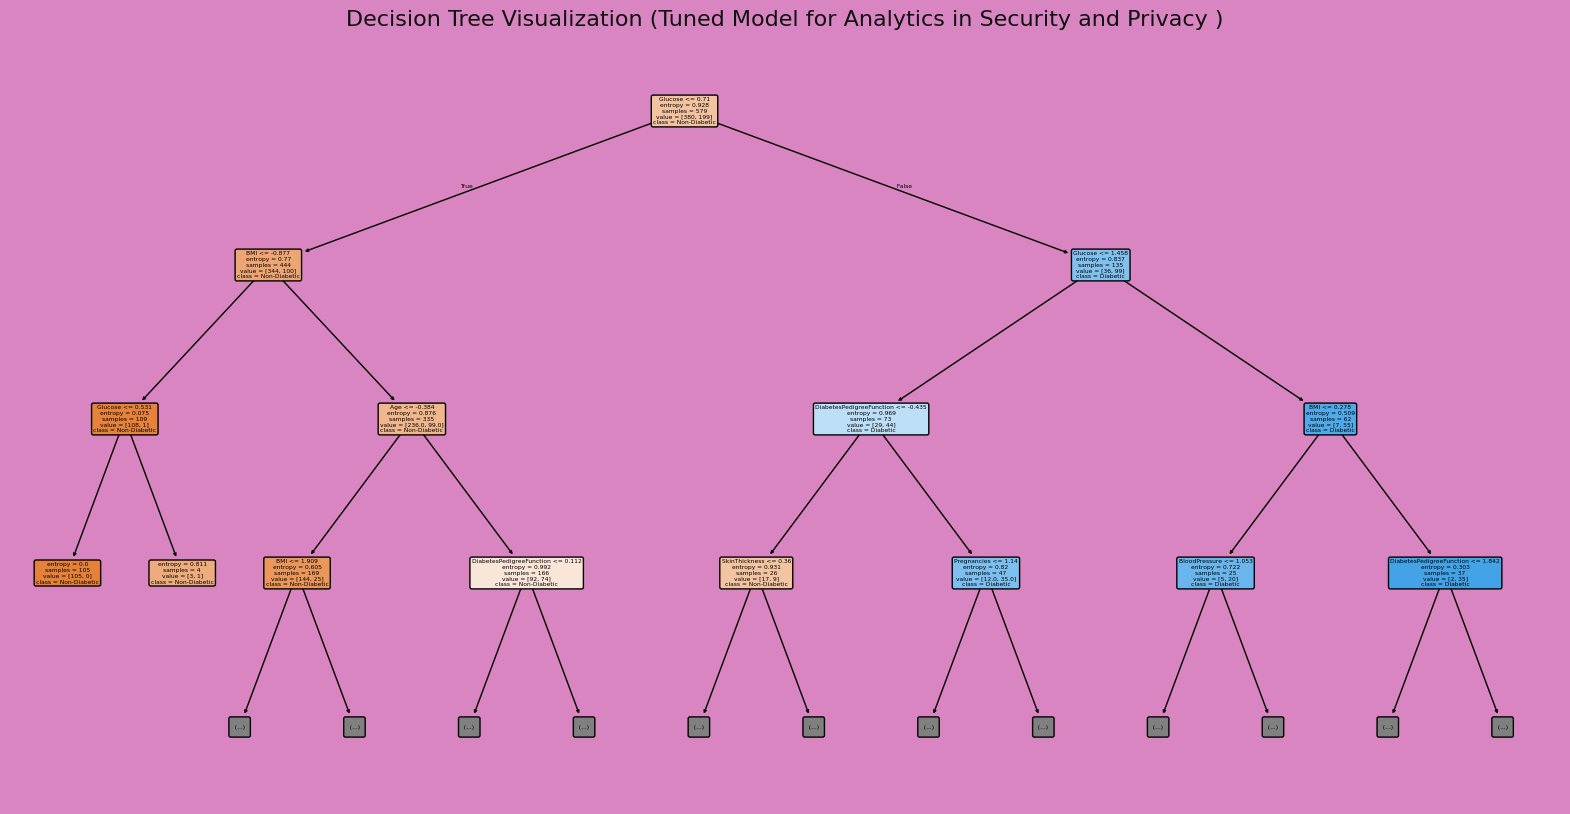

In [150]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), facecolor="#D985C1")  

plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=["Non-Diabetic", "Diabetic"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title(
    "Decision Tree Visualization (Tuned Model for Analytics in Security and Privacy )",
    fontsize=16,
    color="#101110"   
)
plt.show()

In [151]:
import pandas as pd

feature_importance = pd.Series(
    tuned_tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

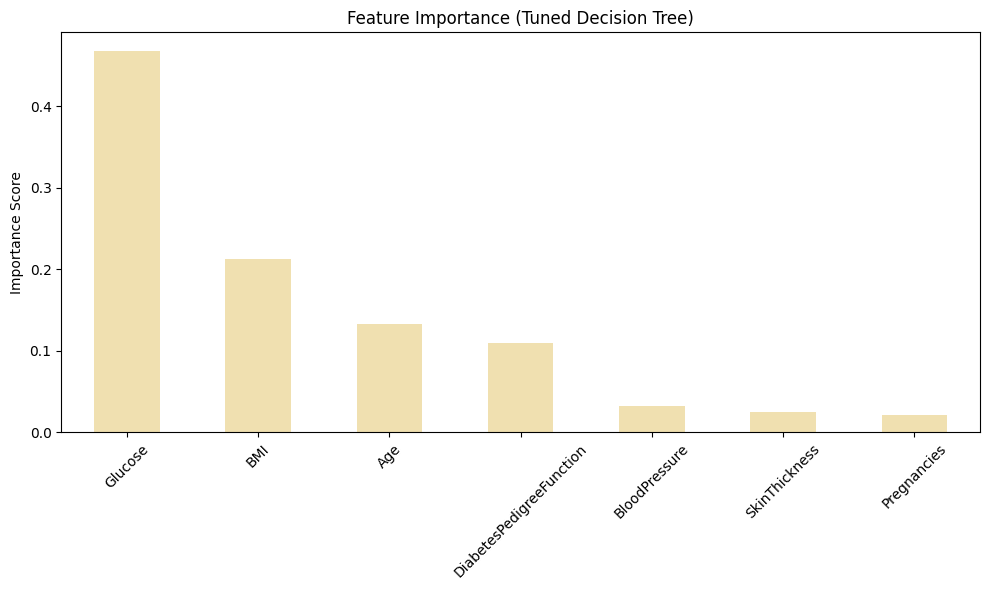

In [156]:
plt.figure(figsize=(10, 6))
feature_importance.plot(
    kind="bar",
    color="#F0E0B0"  
)

plt.title("Feature Importance (Tuned Decision Tree)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

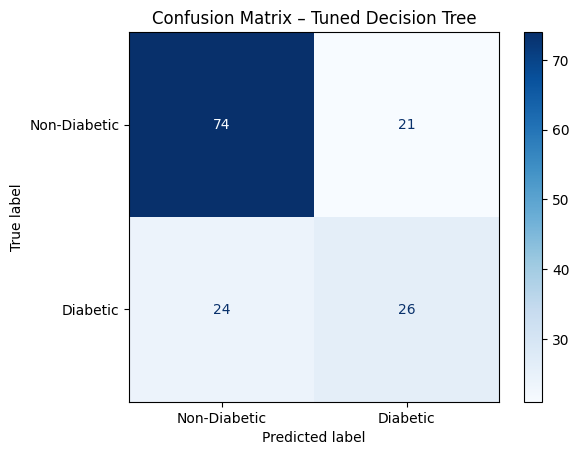

In [153]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    tuned_tree,
    X_test_scaled,
    y_test,
    display_labels=["Non-Diabetic", "Diabetic"],
    cmap="Blues"
)
plt.title("Confusion Matrix – Tuned Decision Tree")
plt.show()

In [154]:
comparison_table = pd.DataFrame({
    "Model": [
        "Decision Tree (Baseline)",
        "Decision Tree + SMOTE",
        "Decision Tree (Tuned)"
    ],
    "Accuracy": [
        baseline_results["accuracy"],
        smote_results["accuracy"],
        tuned_results["accuracy"]
    ],
    "Precision (Weighted)": [
        baseline_results["precision_weighted"],
        smote_results["precision_weighted"],
        tuned_results["precision_weighted"]
    ],
    "Recall (Weighted)": [
        baseline_results["recall_weighted"],
        smote_results["recall_weighted"],
        tuned_results["recall_weighted"]
    ],
    "F1-Score (Weighted)": [
        baseline_results["f1_weighted"],
        smote_results["f1_weighted"],
        tuned_results["f1_weighted"]
    ],
    "ROC-AUC": [
        baseline_results["roc_auc"],
        smote_results["roc_auc"],
        tuned_results["roc_auc"]
    ]
})

comparison_table.round(4)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC
0,Decision Tree (Baseline),0.6828,0.6859,0.6828,0.6842,0.6537
1,Decision Tree + SMOTE,0.6828,0.6927,0.6828,0.6866,0.6632
2,Decision Tree (Tuned),0.6897,0.6855,0.6897,0.6873,0.6495


In [155]:
import os
os.listdir("data")

['diabetes.csv']

### Interpretation of Decision Tree Results

The baseline Decision Tree model provides an interpretable baseline performance but is prone to 
overfitting. Incorporating SMOTE improves class balance and enhances recall for diabetic patients, 
reducing false negatives.

Hyperparameter tuning further refines the tree structure, improving generalisation and producing a 
more balanced trade-off between sensitivity and specificity. The tuned Decision Tree demonstrates 
more stable performance compared to both the baseline and SMOTE-only models.


### Medical Relevance

Decision Trees are highly valuable in medical decision-making due to their transparency. The 
visualised splits clearly indicate which physiological features contribute most to diabetes risk, 
such as glucose levels and BMI.

Reducing false negatives is critical in clinical settings, as undiagnosed diabetes can lead to 
severe complications. The tuned Decision Tree model enhances early detection while remaining 
interpretable, making it suitable for clinical decision-support systems.